<a href="https://colab.research.google.com/github/lautarodibartolo-ae/e8102-exploracion-de-datos/blob/main/bloque-2-distribuciones-y-analisis-de-datos/u3_ejemplos_distribuciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>


# Unidad 3 — Distribuciones de probabilidad, en ejemplos

**Asignatura E8102 · Exploración de datos**

Este notebook acompaña al apunte de la unidad 3. No agrega teoría: toma los cinco ejemplos del
apunte —el bolillero, los rechazos del relevamiento, la duración de la entrevista, las facturas del
auditor y el ingreso de los hogares— y deja mover los parámetros de cada distribución. Cada bloque
dice a qué sección corresponde y qué conviene mirar.

Se lee el apunte primero y se juega con esto después.


## Cómo se usa

Antes de tocar nada: `Archivo` → `Guardar una copia en Drive`. Si no, los cambios se pierden.

Este notebook no pide escribir código. Cada bloque tiene un **formulario** con deslizadores y
listas desplegables. Se mueve un valor y el gráfico se vuelve a dibujar solo.

Tres pasos:

1. Ejecutar todo una vez: `Entorno de ejecución` → `Ejecutar todo`. Tarda unos segundos y deja
   listas las herramientas y los datos.
2. Bajar hasta un bloque, leer el resumen y mover los parámetros del formulario. La celda se
   ejecuta sola con cada cambio.
3. Si un formulario no reacciona, hacer clic adentro y apretar `Shift + Enter`, o volver al paso 1.

El código de cada formulario está oculto a propósito. Si te da curiosidad, `Mostrar código` lo
despliega, pero nada de este notebook requiere leerlo.


## Preparación

Dos celdas. La primera carga las herramientas y la paleta de colores. La segunda carga el
relevamiento de hogares del T8001, que los dos apuntes usan como ejemplo con datos reales.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Circle, Polygon, Rectangle
from cycler import cycler
from fractions import Fraction
from io import StringIO
import scipy
from scipy import stats

# La paleta de las ilustraciones del apunte, para que los gráficos se vean como el mismo material.
CREMA, TEAL, TEAL_PALIDO, MOSTAZA, CORAL, TINTA = (
    "#FEF8EF", "#61A9A1", "#D0E5DE", "#EEA92F", "#F07C52", "#32435D")

plt.rcParams.update({
    "figure.facecolor": CREMA, "axes.facecolor": CREMA, "savefig.facecolor": CREMA,
    "axes.edgecolor": TINTA, "axes.labelcolor": TINTA, "text.color": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": cycler(color=[TEAL, CORAL, MOSTAZA, TINTA]),
    "axes.grid": True, "grid.color": TEAL_PALIDO, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "figure.figsize": (9, 4.5), "figure.dpi": 100,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False, "font.size": 11,
})


def num(x, decimales=4):
    """Número con coma decimal, como en el apunte."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "—"
    if abs(x) < 0.5 * 10 ** -decimales:
        x = 0.0   # evita el "-0,0000"
    return f"{x:,.{decimales}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def frac(k, n):
    """'k/n = 0,xxxx' con la fracción sin simplificar, que es como la escribe el apunte."""
    return f"{k}/{n} = {num(k / n)}"


print("numpy", np.__version__, "| pandas", pd.__version__, "| scipy", scipy.__version__, "| todo listo")


def medidas_discretas(valores, probabilidades):
    """Las cuatro medidas de la unidad 2, sobre una distribución discreta dada por su tabla."""
    x = np.asarray(valores, dtype=float)
    p = np.asarray(probabilidades, dtype=float)
    p = p / p.sum()
    mu = (x * p).sum()
    var = (((x - mu) ** 2) * p).sum()
    sd = np.sqrt(var)
    z = (x - mu) / sd if sd > 0 else np.zeros_like(x)
    return {"E(s)": mu, "σ(s)²": var, "σ(s)": sd,
            "asimetría α₃": (z ** 3 * p).sum() if sd > 0 else np.nan,
            "kurtosis α₄": (z ** 4 * p).sum() if sd > 0 else np.nan}


def barras_distribucion(ax, valores, probabilidades, destacado=None, color=TEAL):
    """Las columnas de una distribución discreta, con un valor resaltado en coral."""
    colores = [CORAL if destacado is not None and v == destacado else color for v in valores]
    ax.bar(valores, probabilidades, color=colores, width=0.7)
    ax.set_ylim(0, max(probabilidades) * 1.25 if max(probabilidades) > 0 else 1)
    ax.set_ylabel("P(s)")


def veredicto(condicion, texto_si, texto_no):
    """Una línea que dice si la condición de una aproximación se cumple."""
    return ("✔ " + texto_si) if condicion else ("✘ " + texto_no)


numpy 2.3.2 | pandas 2.3.2 | scipy 1.17.1 | todo listo


El relevamiento va adentro del notebook, como texto, así que no hace falta conexión. Son **45
visitas a 37 hogares**: ocho hogares recibieron una segunda visita. El apunte de la unidad 2 fija la
regla, la primera visita de cada hogar, y acá se usa la misma en las dos unidades. La copia
publicada está en
[`datos/relevamiento_plano.csv`](https://github.com/lautarodibartolo-ae/e8102-exploracion-de-datos/blob/main/bloque-1-probabilidad-y-variables-aleatorias/datos/relevamiento_plano.csv).


In [2]:
CSV = """id_hogar,localidad,provincia,fecha_visita,encuestador_legajo,encuestador_nombre,encuestador_telefono,personas,ingreso,cobertura_salud,satisfaccion,servicios
1,Ramallo,Buenos Aires,2025-03-14,E04,"Sosa, Diego",3407-419854,3,185000,si,buena,agua;luz;gas
1,Ramallo,Buenos Aires,2025-06-12,E04,"Sosa, Diego",3407-419854,4,201000,si,buena,agua;luz;gas
2,Córdoba,Córdoba,2025-03-15,E02,"Ledesma, Julio",351-4778120,5,240500,no,regular,agua;luz
3,Concepción,Tucumán,2025-03-15,E03,"Bianchi, Ana",381-4551907,2,,,,luz
4,Ramallo,Buenos Aires,2025-03-16,E01,"Rivas, Marta",3407-412233,4,198000,si,buena,agua;luz;gas
5,Ramallo,Buenos Aires,2025-03-16,E04,"Sosa, Diego",3407-419854,1,120000,,,luz
7,Córdoba,Córdoba,2025-03-17,E04,"Sosa, Diego",3407-419854,6,310000,no,mala,agua;luz;gas;cloacas
7,Córdoba,Córdoba,2025-06-13,E04,"Sosa, Diego",3407-419854,6,325000,no,regular,agua;luz;gas;cloacas
8,Concepción,Tucumán,2025-03-17,E03,"Bianchi, Ana",381-4551907,3,175000,si,regular,agua;luz
9,Ramallo,Buenos Aires,2025-03-18,E04,"Sosa, Diego",3407-419854,2,,no,mala,luz;gas
10,Córdoba,Córdoba,2025-03-19,E02,"Ledesma, Julio",351-4778120,4,205000,,,agua;luz;gas
11,Concepción,Tucumán,2025-03-20,E03,"Bianchi, Ana",381-4551907,7,260000,si,buena,agua;luz;gas;cloacas
11,Concepción,Tucumán,2025-06-13,E03,"Bianchi, Ana",381-4551907,7,268000,si,buena,agua;luz;gas;cloacas
13,Ramallo,Buenos Aires,2025-03-20,E04,"Sosa, Diego",3407-419854,3,190000,,,agua;luz
14,Córdoba,Córdoba,2025-03-21,E02,"Ledesma, Julio",351-4778120,2,168000,no,regular,agua
15,Ramallo,Buenos Aires,2025-03-21,E04,"Sosa, Diego",3407-419854,3,172000,si,regular,agua;luz;gas
16,Concepción,Tucumán,2025-03-24,E03,"Bianchi, Ana",381-4551907,4,195000,no,buena,agua;luz
17,Córdoba,Córdoba,2025-03-24,E04,"Sosa, Diego",3407-419854,2,210000,si,regular,agua;luz;gas
18,Córdoba,Córdoba,2025-03-25,E02,"Ledesma, Julio",351-4778120,5,155000,,,luz
19,Ramallo,Buenos Aires,2025-03-25,E04,"Sosa, Diego",3407-419854,3,188000,no,mala,agua;luz
20,Concepción,Tucumán,2025-03-26,E03,"Bianchi, Ana",381-4551907,6,225000,si,buena,agua;luz;gas;cloacas
20,Concepción,Tucumán,2025-06-16,E03,"Bianchi, Ana",381-4551907,5,231000,si,regular,agua;luz;gas;cloacas
21,Ramallo,Buenos Aires,2025-03-26,E04,"Sosa, Diego",3407-419854,2,163000,,,agua;luz
22,Córdoba,Córdoba,2025-03-27,E02,"Ledesma, Julio",351-4778120,4,201000,si,regular,agua;luz;gas
23,Ramallo,Buenos Aires,2025-03-27,E04,"Sosa, Diego",3407-419854,3,179000,no,buena,agua;luz
24,Concepción,Tucumán,2025-03-28,E03,"Bianchi, Ana",381-4551907,5,232000,si,regular,agua;luz;gas
25,Córdoba,Córdoba,2025-03-28,E04,"Sosa, Diego",3407-419854,1,148000,,,luz
26,Ramallo,Buenos Aires,2025-03-31,E01,"Rivas, Marta",3407-412233,4,216000,no,regular,agua;luz;gas
26,Ramallo,Buenos Aires,2025-06-17,E01,"Rivas, Marta",3407-412233,4,222000,no,buena,agua;luz;gas
27,Concepción,Tucumán,2025-03-31,E03,"Bianchi, Ana",381-4551907,2,193000,si,mala,agua;luz
30,Ramallo,Buenos Aires,2025-04-01,E01,"Rivas, Marta",3407-412233,7,244000,si,buena,agua;luz;gas;cloacas
30,Ramallo,Buenos Aires,2025-06-18,E01,"Rivas, Marta",3407-412233,8,259000,si,buena,agua;luz;gas;cloacas
31,Concepción,Tucumán,2025-04-02,E03,"Bianchi, Ana",381-4551907,4,181000,,,agua;luz
32,Córdoba,Córdoba,2025-04-02,E02,"Ledesma, Julio",351-4778120,3,207000,no,regular,agua;luz;gas
33,Ramallo,Buenos Aires,2025-04-02,E04,"Sosa, Diego",3407-419854,5,169000,si,regular,agua;luz
34,Concepción,Tucumán,2025-04-03,E03,"Bianchi, Ana",381-4551907,2,236000,no,buena,agua;luz;gas
35,Córdoba,Córdoba,2025-04-03,E04,"Sosa, Diego",3407-419854,4,152000,,,agua
36,Ramallo,Buenos Aires,2025-04-04,E01,"Rivas, Marta",3407-412233,6,199000,si,mala,agua;luz;gas
36,Ramallo,Buenos Aires,2025-06-19,E01,"Rivas, Marta",3407-412233,6,204000,si,regular,agua;luz;gas
37,Concepción,Tucumán,2025-04-04,E03,"Bianchi, Ana",381-4551907,3,223000,no,regular,agua;luz
38,Córdoba,Córdoba,2025-04-07,E02,"Ledesma, Julio",351-4778120,2,0,si,mala,luz
39,Ramallo,Buenos Aires,2025-04-07,E04,"Sosa, Diego",3407-419854,12,620000,no,buena,agua;luz;gas;cloacas
39,Ramallo,Buenos Aires,2025-06-20,E04,"Sosa, Diego",3407-419854,12,641000,no,regular,agua;luz;gas;cloacas
40,Concepción,Tucumán,2025-04-08,E03,"Bianchi, Ana",381-4551907,4,186000,,,agua;luz
42,Ramallo,Buenos Aires,2025-04-09,E01,"Rivas, Marta",3407-412233,2,176000,no,mala,agua;luz"""

visitas = pd.read_csv(StringIO(CSV), parse_dates=["fecha_visita"])
primera = (visitas.sort_values("fecha_visita").drop_duplicates("id_hogar", keep="first")
           .sort_values("id_hogar").reset_index(drop=True))
segunda = (visitas.sort_values("fecha_visita").drop_duplicates("id_hogar", keep="last")
           .sort_values("id_hogar").reset_index(drop=True))
hogares = primera   # la regla del apunte: un hogar, su primera visita

print(f"{len(visitas)} visitas, {len(hogares)} hogares, {hogares['localidad'].nunique()} localidades")
print("personas por hogar, primera visita:",
      hogares["personas"].value_counts().sort_index().to_dict())


45 visitas, 37 hogares, 3 localidades
personas por hogar, primera visita: {1: 2, 2: 9, 3: 8, 4: 8, 5: 4, 6: 3, 7: 2, 12: 1}


---
# 1. Una familia, y el parámetro que elige cuál es

*Apunte, secciones 2.1 y 3.7.*

Una distribución con nombre no es una distribución: es una **familia** de distribuciones que
comparten la misma fórmula. Cuál de todas es depende de los **parámetros**. La binomial tiene dos,
`n` y `p`, y cada uno hace una cosa distinta.

`p` decide la asimetría. Con `p = 0,5` la distribución es simétrica; con `p` chico se estira hacia
la derecha y con `p` grande hacia la izquierda. `n` decide la simetría de a poco: con `p` fijo y `n`
creciendo, la binomial se vuelve más simétrica y más parecida a una campana, sea cual sea el `p`.

Las columnas pálidas del fondo son las otras binomiales con el mismo `n`. La coral es la que eligen
los dos deslizadores. Mové `p` y mirá el signo de `α₃`; después dejá `p` fijo en 0,1 y subí `n`.


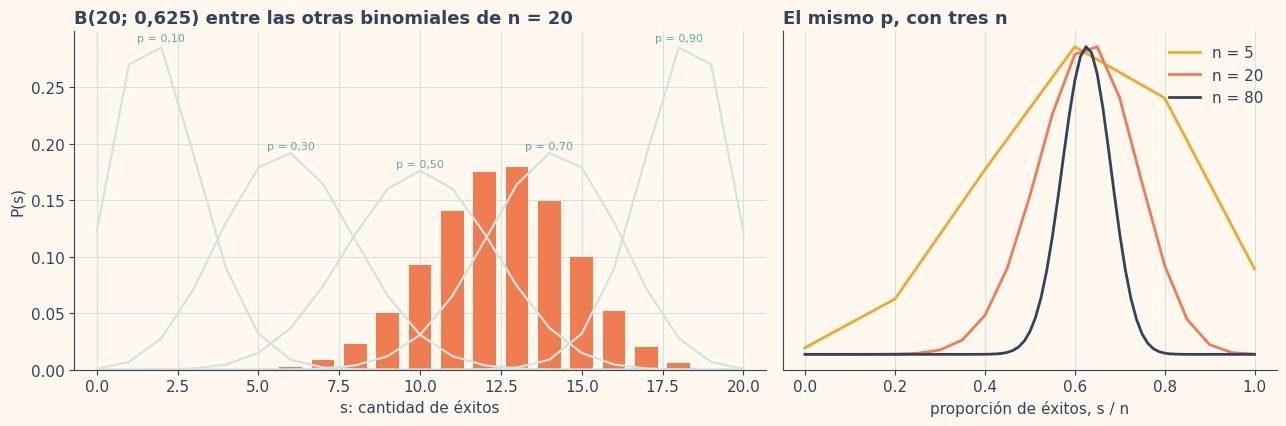

X ~ B(20; 0,625)
E(s) = n × p = 12,5000     σ(s)² = n × p × q = 4,6875     σ(s) = 2,1651
α₃ = -0,1155   cola hacia la izquierda, porque p > 0,5
El producto p × q vale 0,2344, y es máximo en 0,25 cuando p = 0,5.


In [3]:
#@title La familia binomial { run: "auto", display-mode: "form" }

n = 20  #@param {type:"slider", min:1, max:80, step:1}
p = 0.625  #@param {type:"slider", min:0.05, max:0.95, step:0.025}

valores = np.arange(0, n + 1)
elegida = stats.binom(n, p).pmf(valores)
familia = {otro: stats.binom(n, otro).pmf(valores) for otro in (0.1, 0.3, 0.5, 0.7, 0.9)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.4, 1]})
for otro, pmf in familia.items():
    ax1.plot(valores, pmf, color=TEAL_PALIDO, linewidth=1.6)
    ax1.text(n * otro, pmf.max() * 1.02, f"p = {num(otro, 2)}", ha="center", fontsize=8, color=TEAL)
ax1.bar(valores, elegida, color=CORAL, width=0.7)
ax1.set_xlim(-0.7, n + 0.7); ax1.set_xlabel("s: cantidad de éxitos"); ax1.set_ylabel("P(s)")
ax1.set_title(f"B({n}; {num(p, 3)}) entre las otras binomiales de n = {n}")

for tamano, color in zip([5, n, 80], [MOSTAZA, CORAL, TINTA]):
    x = np.arange(0, tamano + 1)
    pmf = stats.binom(tamano, p).pmf(x)
    ax2.plot(x / tamano, pmf / pmf.max(), color=color, linewidth=2, label=f"n = {tamano}")
ax2.set_xlabel("proporción de éxitos, s / n"); ax2.set_yticks([])
ax2.legend(loc="upper right"); ax2.set_title("El mismo p, con tres n")
plt.tight_layout(); plt.show()

m = medidas_discretas(valores, elegida)
print(f"X ~ B({n}; {num(p, 3)})")
print(f"E(s) = n × p = {num(m['E(s)'], 4)}     σ(s)² = n × p × q = {num(m['σ(s)²'], 4)}     "
      f"σ(s) = {num(m['σ(s)'], 4)}")
print(f"α₃ = {num(m['asimetría α₃'], 4)}   "
      + ("simétrica: p = 0,5" if abs(p - 0.5) < 1e-9 else
         "cola hacia la derecha, porque p < 0,5" if p < 0.5 else
         "cola hacia la izquierda, porque p > 0,5"))
print(f"El producto p × q vale {num(p * (1 - p), 4)}, y es máximo en 0,25 cuando p = 0,5.")


---
# 2. La binomial, término por término

*Apunte, secciones 3.3 a 3.6.*

La fórmula tiene tres factores, y cada uno sale de algo de la unidad 1:

```
P(s) = C(n, s) × p^s × q^(n − s)
```

`p^s` es la probabilidad de que salgan los `s` éxitos, `q^(n − s)` la de que los demás sean
fracasos, y `C(n, s)` cuenta en cuántos órdenes distintos puede pasar. El formulario muestra los
tres números por separado y su producto.

Los valores de fábrica son los de la sección 3.5: veinte extracciones del bolillero con reposición,
`p = 0,625`, y siete blancas. Dan `C(20, 7) = 77.520` y `P(7) = 0,0084`. Mové `s` y mirá contra la
esperanza de 12,5: siete es un resultado bajo, y por eso su probabilidad es chica.


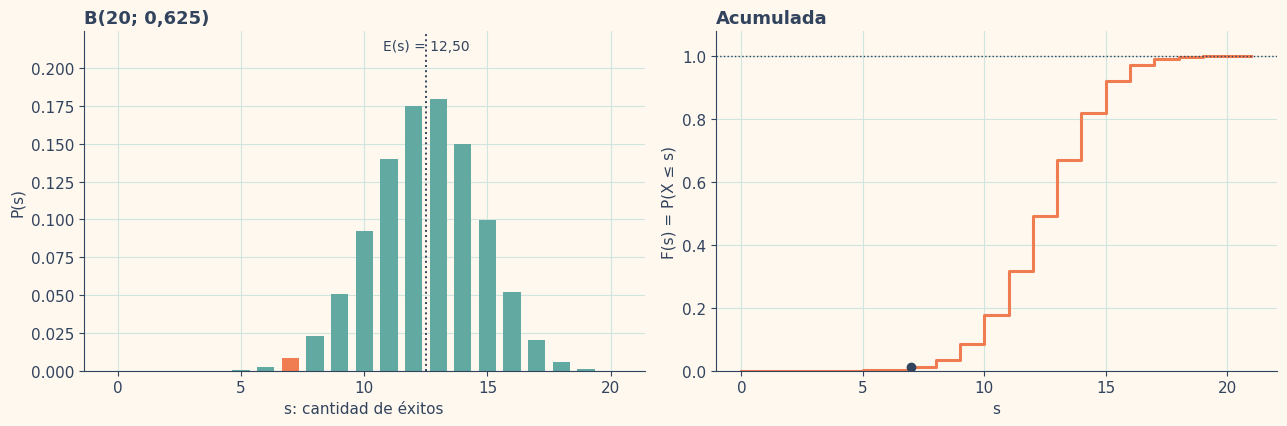

C(20, 7) = 77.520     ← en cuántos órdenes caen los 7 éxitos
p^s       = 0,625^7 = 0.03725290298
q^(n − s) = 0,375^13 = 2.900056643e-06
P(7) = 77.520 × 0.0372529 × 2.90006e-06 = 0,008375
scipy.stats.binom(20, 0,625).pmf(7) = 0,008375   (el mismo número)

E(s) = n × p = 12,5000     σ(s)² = n × p × q = 4,6875     σ(s) = 2,1651
P(X ≤ 7) = 0,0116     P(X ≥ 7) = 0,9968
Los 20 ensayos tienen 1.048.576 secuencias posibles; la fórmula no las enumera.


In [4]:
#@title P(s) = C(n, s) × p^s × q^(n − s) { run: "auto", display-mode: "form" }

n = 20  #@param {type:"slider", min:1, max:60, step:1}
p = 0.625  #@param {type:"slider", min:0.05, max:0.95, step:0.025}
s = 7  #@param {type:"slider", min:0, max:60, step:1}

from math import comb

s = min(s, n)
q = 1 - p
valores = np.arange(0, n + 1)
pmf = stats.binom(n, p).pmf(valores)
acumulada = np.cumsum(pmf)
combinatorio = comb(n, s)
producto = combinatorio * p ** s * q ** (n - s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
barras_distribucion(ax1, valores, pmf, destacado=s)
ax1.axvline(n * p, color=TINTA, linestyle=":", linewidth=1.4)
ax1.text(n * p, pmf.max() * 1.18, f"E(s) = {num(n * p, 2)}", ha="center", fontsize=10)
ax1.set_xlabel("s: cantidad de éxitos"); ax1.set_title(f"B({n}; {num(p, 3)})")
ax2.step(np.append(valores, n + 1), np.append(acumulada, 1), where="post", color=CORAL, linewidth=2.2)
ax2.axhline(1, color=TINTA, linestyle=":", linewidth=1)
ax2.plot([s], [acumulada[s]], "o", color=TINTA)
ax2.set_ylim(0, 1.08); ax2.set_xlabel("s"); ax2.set_ylabel("F(s) = P(X ≤ s)")
ax2.set_title("Acumulada")
plt.tight_layout(); plt.show()

print(f"C({n}, {s}) = " + f"{combinatorio:,}".replace(",", ".") + f"     ← en cuántos órdenes caen los {s} éxitos")
print(f"p^s       = {num(p, 3)}^{s} = {p ** s:.10g}")
print(f"q^(n − s) = {num(q, 3)}^{n - s} = {q ** (n - s):.10g}")
print(f"P({s}) = " + f"{combinatorio:,}".replace(",", ".") + f" × {p ** s:.6g} × {q ** (n - s):.6g} = {num(producto, 6)}")
print(f"scipy.stats.binom({n}, {num(p, 3)}).pmf({s}) = {num(pmf[s], 6)}   "
      + ("(el mismo número)" if abs(producto - pmf[s]) < 1e-12 else "(atención: no coinciden)"))
print()
print(f"E(s) = n × p = {num(n * p, 4)}     σ(s)² = n × p × q = {num(n * p * q, 4)}     σ(s) = {num(np.sqrt(n * p * q), 4)}")
print(f"P(X ≤ {s}) = {num(acumulada[s], 4)}     P(X ≥ {s}) = {num(1 - acumulada[s] + pmf[s], 4)}")
print(f"Los {n} ensayos tienen " + f"{2 ** n:,}".replace(",", ".") + " secuencias posibles; la fórmula no las enumera.")


---
# 3. La multinomial: más de dos resultados por ensayo

*Apunte, sección 3.8.*

La condición 3 de la binomial exige dos resultados por ensayo. La **multinomial** la levanta: la
variable es policotómica y todo lo demás queda igual.

El ejemplo del apunte es el del auditor. De cada factura, el 10% tiene un error formal, el 1% un
error material y el 89% ninguno. Se eligen 10 al azar y se pregunta por 2 del primer grupo, 1 del
segundo y 7 del tercero: `0,0159`.

Debajo del resultado está el control del apunte, que resuelve lo mismo con **dos binomiales
sucesivas**: primero se dicotomiza en "con error" contra "sin error", y después se pregunta, dentro
de las que tienen error, cuántas son del primer tipo. El camino largo confirma el corto.


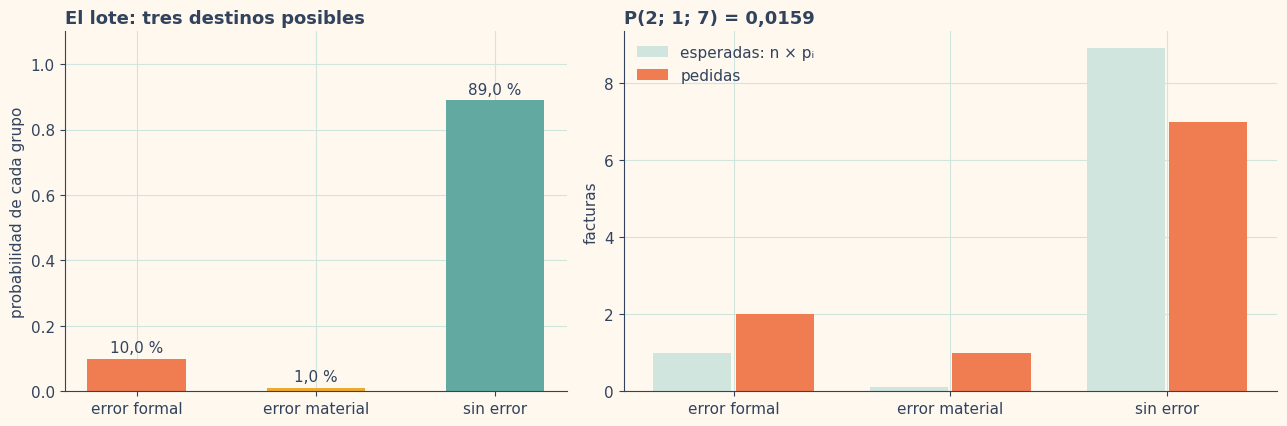

P(2; 1; 7) = 10! / (2! × 1! × 7!) × 0,10^2 × 0,01^1 × 0,89^7
             = 0,015923 = 1,59 %

El control con dos binomiales sucesivas, como en el apunte:
  1) con error contra sin error, p = 0,1100, s = 3:  0,070646
  2) de esas 3, que 2 sean del tipo formal, p = 0,9091:  0,225394
  compuesta: 0,070646 × 0,225394 = 0,015923
  Los dos caminos dan lo mismo.


In [5]:
#@title Las facturas del auditor { run: "auto", display-mode: "form" }

facturas_elegidas = 10  #@param {type:"slider", min:2, max:30, step:1}
porcentaje_error_formal = 10  #@param {type:"slider", min:1, max:40, step:1}
porcentaje_error_material = 1  #@param {type:"slider", min:1, max:20, step:1}
con_error_formal = 2  #@param {type:"slider", min:0, max:30, step:1}
con_error_material = 1  #@param {type:"slider", min:0, max:30, step:1}

from math import comb, factorial

n = facturas_elegidas
p1, p2 = porcentaje_error_formal / 100, porcentaje_error_material / 100
p3 = 1 - p1 - p2
s1, s2 = min(con_error_formal, n), min(con_error_material, n)
s3 = n - s1 - s2

if p3 <= 0:
    print("Los dos porcentajes de error suman 100% o más: no queda lugar para las facturas sin error.")
elif s3 < 0:
    print(f"Se piden {s1} + {s2} = {s1 + s2} facturas con error sobre {n} elegidas: no alcanza.")
else:
    multinomial = (factorial(n) / (factorial(s1) * factorial(s2) * factorial(s3))
                   * p1 ** s1 * p2 ** s2 * p3 ** s3)
    p_error = p1 + p2
    paso1 = comb(n, s1 + s2) * p_error ** (s1 + s2) * (1 - p_error) ** s3
    condicional = p1 / p_error
    paso2 = comb(s1 + s2, s1) * condicional ** s1 * (1 - condicional) ** s2

    grupos = ["error formal", "error material", "sin error"]
    probabilidades = [p1, p2, p3]
    pedidos = [s1, s2, s3]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.3]})
    ax1.bar(grupos, probabilidades, color=[CORAL, MOSTAZA, TEAL], width=0.55)
    for i, v in enumerate(probabilidades):
        ax1.text(i, v + 0.02, f"{num(100 * v, 1)} %", ha="center")
    ax1.set_ylim(0, 1.1); ax1.set_ylabel("probabilidad de cada grupo")
    ax1.set_title("El lote: tres destinos posibles")
    esperados = [n * v for v in probabilidades]
    posiciones = np.arange(3)
    ax2.bar(posiciones - 0.19, esperados, width=0.36, color=TEAL_PALIDO, label="esperadas: n × pᵢ")
    ax2.bar(posiciones + 0.19, pedidos, width=0.36, color=CORAL, label="pedidas")
    ax2.set_xticks(posiciones); ax2.set_xticklabels(grupos)
    ax2.set_ylabel("facturas"); ax2.legend(loc="upper left")
    ax2.set_title(f"P({s1}; {s2}; {s3}) = {num(multinomial, 4)}")
    plt.tight_layout(); plt.show()

    print(f"P({s1}; {s2}; {s3}) = {n}! / ({s1}! × {s2}! × {s3}!) × {num(p1, 2)}^{s1} × "
          f"{num(p2, 2)}^{s2} × {num(p3, 2)}^{s3}")
    print(f"             = {num(multinomial, 6)} = {num(100 * multinomial, 2)} %")
    print()
    print("El control con dos binomiales sucesivas, como en el apunte:")
    print(f"  1) con error contra sin error, p = {num(p_error, 4)}, s = {s1 + s2}:  {num(paso1, 6)}")
    print(f"  2) de esas {s1 + s2}, que {s1} sean del tipo formal, p = {num(condicional, 4)}:  {num(paso2, 6)}")
    print(f"  compuesta: {num(paso1, 6)} × {num(paso2, 6)} = {num(paso1 * paso2, 6)}")
    print("  " + ("Los dos caminos dan lo mismo." if abs(paso1 * paso2 - multinomial) < 1e-12
                  else "Atención: los dos caminos no coinciden."))


---
# 4. La hipergeométrica, y el factor de corrección

*Apunte, secciones 4.1 a 4.4, y 7.2.*

La hipergeométrica es la misma pregunta sin reposición. Los parámetros describen la población: hay
`N` elementos, de los cuales `Np` son éxitos, y se extraen `n`.

Las dos distribuciones tienen la **misma esperanza**. Lo que cambia es la varianza, por el **factor
de corrección por población finita** `(N − n)/(N − 1)`, que siempre vale entre 0 y 1: sin reposición
la dispersión es menor.

Los valores de fábrica son el bolillero de la unidad 2, `N = 8`, `Np = 5`, `n = 2`, con sus
`0,1071`, `0,5357` y `0,3571`. Agrandá `N` sin tocar `n` y mirá dos cosas a la vez: el factor se
acerca a 1 y las dos distribuciones se superponen. Cuando `n / N ≤ 0,05`, la binomial ya alcanza,
que es la aproximación de la sección 7.2.


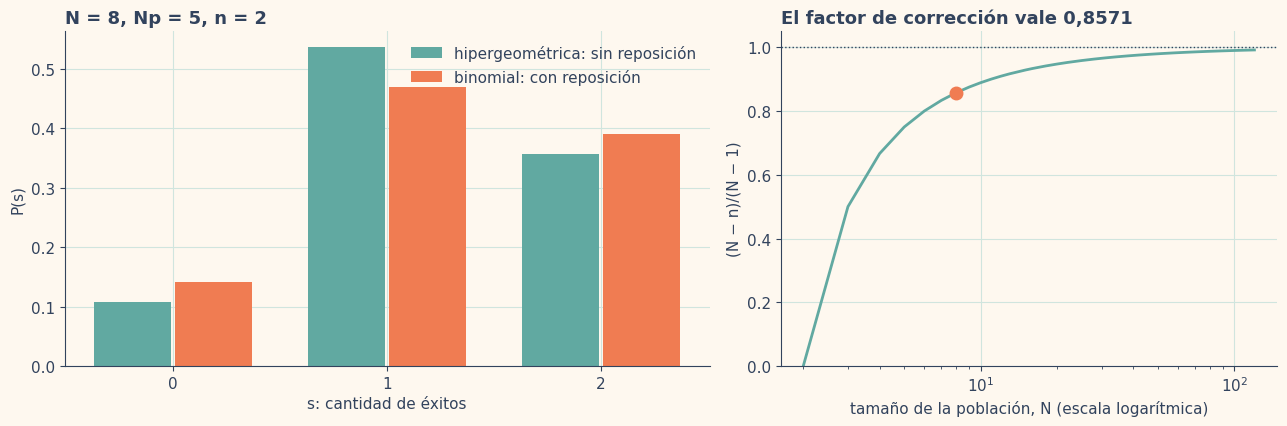

,hipergeométrica,binomial,diferencia
s,,,
0,"0,1071","0,1406","-0,0335"
1,"0,5357","0,4688","0,0670"
2,"0,3571","0,3906","-0,0335"


E(s) = n × Np/N = 1,2500     y la binomial da n × p = 1,2500: la reposición no cambia la esperanza.
σ(s)² hipergeométrica = 0,4018     σ(s)² binomial = 0,4688
n / N = 0,2500   ✘ pasa el 5%: las dos distribuciones se separan y hay que usar la hipergeométrica.


In [6]:
#@title Sin reposición contra con reposición { run: "auto", display-mode: "form" }

poblacion_N = 8  #@param {type:"slider", min:4, max:600, step:1}
exitos_en_la_poblacion = 5  #@param {type:"slider", min:1, max:600, step:1}
extracciones = 2  #@param {type:"slider", min:1, max:40, step:1}

N = poblacion_N
Np = min(exitos_en_la_poblacion, N - 1)
Nq = N - Np
n = min(extracciones, N)
p = Np / N

valores = np.arange(max(0, n - Nq), min(n, Np) + 1)
hiper = stats.hypergeom(M=N, n=Np, N=n).pmf(valores)
bino = stats.binom(n, p).pmf(valores)
factor = (N - n) / (N - 1) if N > 1 else 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
ax1.bar(valores - 0.19, hiper, width=0.36, color=TEAL, label="hipergeométrica: sin reposición")
ax1.bar(valores + 0.19, bino, width=0.36, color=CORAL, label="binomial: con reposición")
ax1.set_xticks(valores); ax1.set_xlabel("s: cantidad de éxitos"); ax1.set_ylabel("P(s)")
ax1.legend(loc="upper right"); ax1.set_title(f"N = {N}, Np = {Np}, n = {n}")

tamanos = np.unique(np.clip(np.round(np.geomspace(max(n, 2), max(n * 60, 60), 40)).astype(int), n, None))
factores = (tamanos - n) / (tamanos - 1)
ax2.plot(tamanos, factores, color=TEAL, linewidth=2)
ax2.plot([N], [factor], "o", color=CORAL, markersize=9)
ax2.set_xscale("log"); ax2.set_ylim(0, 1.05)
ax2.axhline(1, color=TINTA, linestyle=":", linewidth=1)
ax2.set_xlabel("tamaño de la población, N (escala logarítmica)")
ax2.set_ylabel("(N − n)/(N − 1)")
ax2.set_title(f"El factor de corrección vale {num(factor, 4)}")
plt.tight_layout(); plt.show()

tabla = pd.DataFrame({"s": valores,
                      "hipergeométrica": [num(v) for v in hiper],
                      "binomial": [num(v) for v in bino],
                      "diferencia": [num(a - b) for a, b in zip(hiper, bino)]}).set_index("s")
display(tabla)
print(f"E(s) = n × Np/N = {num(n * p, 4)}     y la binomial da n × p = {num(n * p, 4)}: la reposición no cambia la esperanza.")
print(f"σ(s)² hipergeométrica = {num(n * p * (1 - p) * factor, 4)}     σ(s)² binomial = {num(n * p * (1 - p), 4)}")
print(f"n / N = {num(n / N, 4)}   " + veredicto(n / N <= 0.05,
      "está en el 5% o por debajo: la binomial aproxima bien (sección 7.2).",
      "pasa el 5%: las dos distribuciones se separan y hay que usar la hipergeométrica."))
if n == N:
    print("Con n = N se extrae toda la población: el factor vale 0 y no queda nada librado al azar.")


---
# 5. La Poisson, y la escala del intervalo

*Apunte, secciones 5.1 a 5.5.*

Cuando no hay una cantidad fija de ensayos y lo que se cuenta son eventos en un intervalo, el modelo
es la **Poisson**. Tiene un solo parámetro, `λ`, que es la cantidad promedio de eventos por
intervalo, y su particularidad es que la esperanza y la varianza valen las dos `λ`.

El ejemplo del apunte son los rechazos del relevamiento, con `λ = 2` por jornada. Con esos valores
salen los `0,1353` de la tabla de la sección 5.5 y el `P(s ≥ 3) = 0,3233` del complemento.

El segundo deslizador es el que más errores evita. `λ` está atado al tamaño del intervalo: si son
2 rechazos por jornada, en una semana de cinco jornadas son 10, no 2. Moverlo cambia el `λ` de la
pregunta, y el gráfico se corre entero.


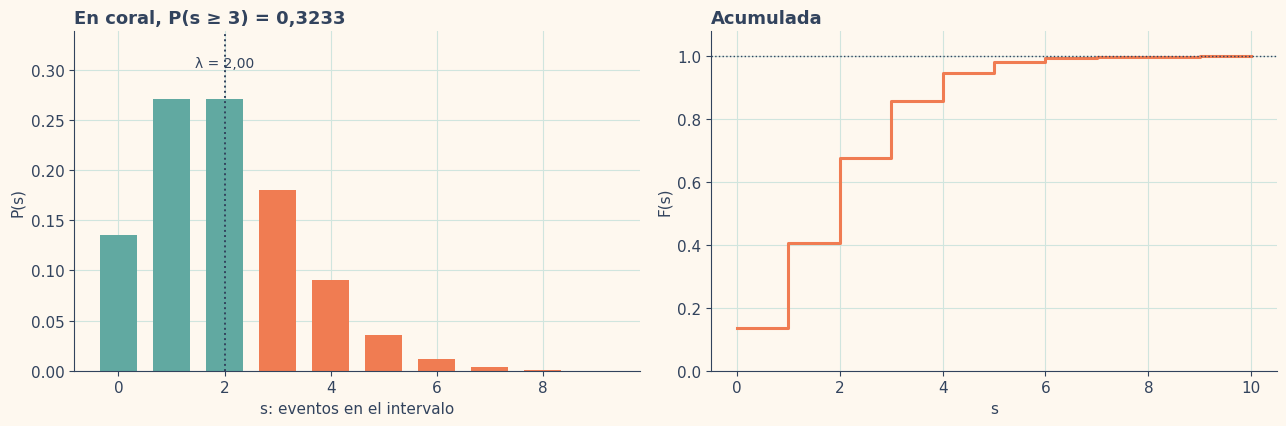

,P(s),F(s)
s,,
0,"0,1353","0,1353"
1,"0,2707","0,4060"
2,"0,2707","0,6767"
3,"0,1804","0,8571"
4,"0,0902","0,9473"
5,"0,0361","0,9834"
6,"0,0120","0,9955"
7,"0,0034","0,9989"


λ de la pregunta = 2,00 por intervalo × 1 = 2,00
P(0) = e^(−λ) = 0,1353     P(s ≥ 3) = 1 − F(2) = 0,3233
E(s) = λ = 2,0000     σ(s)² = λ = 2,0000     σ(s) = √λ = 1,4142
Con λ entero, los valores 1 y 2 tienen la misma probabilidad: 0,2707 y 0,2707.


In [7]:
#@title Eventos por intervalo { run: "auto", display-mode: "form" }

lambda_por_intervalo = 2.0  #@param {type:"slider", min:0.5, max:15, step:0.5}
intervalos_de_la_pregunta = 1  #@param {type:"slider", min:1, max:12, step:1}
s_de_interes = 3  #@param {type:"slider", min:0, max:40, step:1}

lam = lambda_por_intervalo * intervalos_de_la_pregunta
X = stats.poisson(lam)
tope = int(stats.poisson(lam).ppf(0.9995)) + 1
valores = np.arange(0, tope + 1)
pmf = X.pmf(valores)
acumulada = X.cdf(valores)
s = min(s_de_interes, tope)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
colores = [CORAL if v >= s else TEAL for v in valores]
ax1.bar(valores, pmf, color=colores, width=0.7)
ax1.axvline(lam, color=TINTA, linestyle=":", linewidth=1.4)
ax1.text(lam, pmf.max() * 1.12, f"λ = {num(lam, 2)}", ha="center", fontsize=10)
ax1.set_ylim(0, pmf.max() * 1.25)
ax1.set_xlabel("s: eventos en el intervalo"); ax1.set_ylabel("P(s)")
ax1.set_title(f"En coral, P(s ≥ {s}) = {num(1 - X.cdf(s - 1), 4)}")
ax2.step(np.append(valores, tope + 1), np.append(acumulada, 1), where="post", color=CORAL, linewidth=2.2)
ax2.axhline(1, color=TINTA, linestyle=":", linewidth=1)
ax2.set_ylim(0, 1.08); ax2.set_xlabel("s"); ax2.set_ylabel("F(s)")
ax2.set_title("Acumulada")
plt.tight_layout(); plt.show()

filas = valores[:min(len(valores), 8)]
tabla = pd.DataFrame({"s": filas, "P(s)": [num(X.pmf(v)) for v in filas],
                      "F(s)": [num(X.cdf(v)) for v in filas]}).set_index("s")
display(tabla)
print(f"λ de la pregunta = {num(lambda_por_intervalo, 2)} por intervalo × {intervalos_de_la_pregunta} "
      f"= {num(lam, 2)}")
print(f"P(0) = e^(−λ) = {num(X.pmf(0), 4)}     P(s ≥ {s}) = 1 − F({s - 1}) = {num(1 - X.cdf(s - 1), 4)}")
print(f"E(s) = λ = {num(lam, 4)}     σ(s)² = λ = {num(lam, 4)}     σ(s) = √λ = {num(np.sqrt(lam), 4)}")
if intervalos_de_la_pregunta > 1:
    print(f"Sin convertir la escala, la respuesta sería la de λ = {num(lambda_por_intervalo, 2)}: "
          f"P(s ≥ {s}) daría {num(1 - stats.poisson(lambda_por_intervalo).cdf(s - 1), 4)}, que contesta otra pregunta.")
if float(lam).is_integer() and lam >= 1:
    print(f"Con λ entero, los valores {int(lam) - 1} y {int(lam)} tienen la misma probabilidad: "
          f"{num(X.pmf(lam - 1), 4)} y {num(X.pmf(lam), 4)}.")


---
# 6. La normal: las tres franjas, el área y el camino inverso

*Apunte, secciones 6.2 a 6.7.*

La normal tiene dos parámetros, la media `μ` y el desvío `σ`. La media corre la curva sobre la recta
y el desvío la hace más angosta o más ancha. La probabilidad de un intervalo es el **área** bajo la
curva, y las tres franjas del `68`, el `95` y el `99,7` permiten leer cualquier normal sin calcular
nada.

El ejemplo es la duración de la entrevista, `N(35, 8)`. Con esos valores salen los tres resultados
de la sección 6.7: más de 45 minutos el 10,56%, entre 30 y 40 el 46,80%, y el 5% más largo por
encima de 48,16 minutos.

El panel de la derecha hace el **camino inverso**: se fija el área de la cola y se busca el valor
que la deja. Es el cálculo que arma los intervalos de confianza de la unidad 6 y los cuartiles de la
unidad 4.


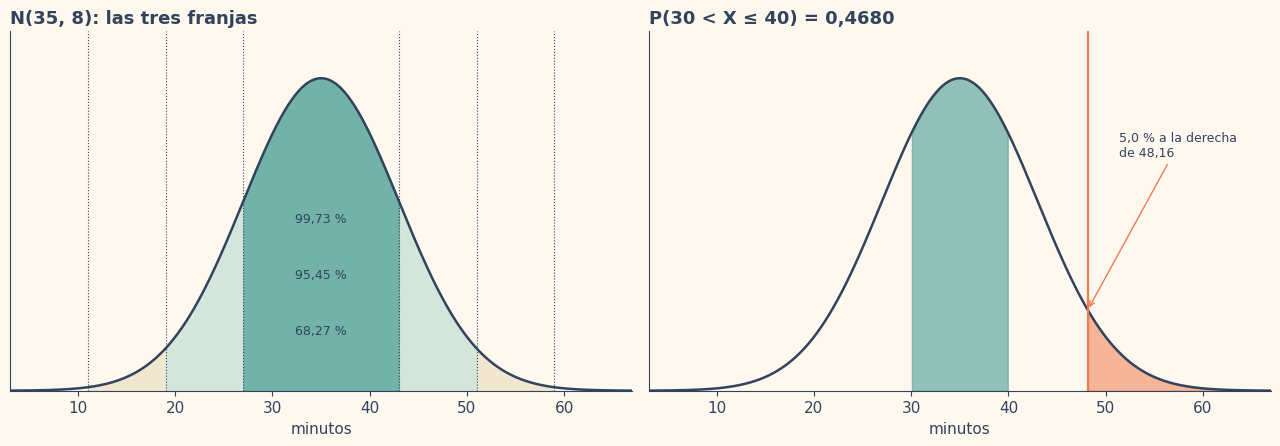

Z de 40 = (40 − 35) / 8 = 0,6250
P(X ≤ 40) = 0,7340     P(X > 40) = 0,2660     P(30 < X ≤ 40) = 0,4680
Camino inverso: el valor que deja el 5,0 % a la derecha es μ + z × σ = 35 + 1,6449 × 8 = 48,16



,de,a,área
intervalo,,,
μ ± 1σ,"27,00","43,00","68,27 %"
μ ± 2σ,"19,00","51,00","95,45 %"
μ ± 3σ,"11,00","59,00","99,73 %"


In [8]:
#@title Área bajo la normal, y el cuantil { run: "auto", display-mode: "form" }

media = 35  #@param {type:"slider", min:0, max:100, step:1}
desvio = 8  #@param {type:"slider", min:1, max:30, step:1}
desde = 30  #@param {type:"slider", min:-20, max:140, step:1}
hasta = 40  #@param {type:"slider", min:-20, max:140, step:1}
cola_derecha_en_porciento = 5.0  #@param {type:"slider", min:0.5, max:50, step:0.5}

a, b = sorted([desde, hasta])
X = stats.norm(media, desvio)
izq, der = media - 4 * desvio, media + 4 * desvio
xs = np.linspace(izq, der, 800)
corte = X.ppf(1 - cola_derecha_en_porciento / 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
ax1.plot(xs, X.pdf(xs), color=TINTA, linewidth=1.8)
for k, color, etiqueta in [(3, "#EFE3CB", "99,73 %"), (2, TEAL_PALIDO, "95,45 %"), (1, TEAL, "68,27 %")]:
    zona = (xs >= media - k * desvio) & (xs <= media + k * desvio)
    ax1.fill_between(xs[zona], X.pdf(xs[zona]), color=color, alpha=0.85)
    ax1.text(media, X.pdf(media) * (0.18 * k), etiqueta, ha="center", fontsize=9, color=TINTA)
for k in (1, 2, 3):
    for lado in (-1, 1):
        ax1.axvline(media + lado * k * desvio, color=TINTA, linewidth=0.8, linestyle=":")
ax1.set_xlim(izq, der); ax1.set_ylim(0, X.pdf(media) * 1.15); ax1.set_yticks([])
ax1.set_xlabel("minutos"); ax1.grid(False)
ax1.set_title(f"N({media}, {desvio}): las tres franjas")

ax2.plot(xs, X.pdf(xs), color=TINTA, linewidth=1.8)
zona = (xs >= a) & (xs <= b)
ax2.fill_between(xs[zona], X.pdf(xs[zona]), color=TEAL, alpha=0.7)
cola = xs >= corte
ax2.fill_between(xs[cola], X.pdf(xs[cola]), color=CORAL, alpha=0.55)
ax2.axvline(corte, color=CORAL, linewidth=1.6)
ax2.annotate(f"{num(cola_derecha_en_porciento, 1)} % a la derecha\nde {num(corte, 2)}",
             xy=(corte, X.pdf(corte)), xytext=(corte + 0.4 * desvio, X.pdf(media) * 0.75),
             fontsize=9, arrowprops=dict(arrowstyle="->", color=CORAL))
ax2.set_xlim(izq, der); ax2.set_ylim(0, X.pdf(media) * 1.15); ax2.set_yticks([])
ax2.set_xlabel("minutos"); ax2.grid(False)
ax2.set_title(f"P({a} < X ≤ {b}) = {num(X.cdf(b) - X.cdf(a), 4)}")
plt.tight_layout(); plt.show()

print(f"Z de {b} = ({b} − {media}) / {desvio} = {num((b - media) / desvio, 4)}")
print(f"P(X ≤ {b}) = {num(X.cdf(b), 4)}     P(X > {b}) = {num(1 - X.cdf(b), 4)}     "
      f"P({a} < X ≤ {b}) = {num(X.cdf(b) - X.cdf(a), 4)}")
print(f"Camino inverso: el valor que deja el {num(cola_derecha_en_porciento, 1)} % a la derecha es "
      f"μ + z × σ = {media} + {num(stats.norm.ppf(1 - cola_derecha_en_porciento / 100), 4)} × {desvio} "
      f"= {num(corte, 2)}")
print()
display(pd.DataFrame({
    "intervalo": ["μ ± 1σ", "μ ± 2σ", "μ ± 3σ"],
    "de": [num(media - k * desvio, 2) for k in (1, 2, 3)],
    "a": [num(media + k * desvio, 2) for k in (1, 2, 3)],
    "área": [num(100 * (X.cdf(media + k * desvio) - X.cdf(media - k * desvio)), 2) + " %" for k in (1, 2, 3)],
}).set_index("intervalo"))
if media - 3 * desvio < 0:
    print(f"Atención: μ − 3σ = {num(media - 3 * desvio, 2)} es negativo. La normal asigna "
          f"{num(100 * X.cdf(0), 2)} % de probabilidad a valores menores que cero, que una duración no admite "
          "(sección 6.8).")


---
# 7. Las cuatro aproximaciones, y la corrección por continuidad

*Apunte, secciones 7.2 a 7.6.*

Cumplidas ciertas condiciones, una distribución se puede reemplazar por otra más simple. Hoy el
cálculo exacto sale con una línea de código, así que lo que importa de las aproximaciones es lo que
dicen: **cuándo dos modelos describen casi lo mismo**.

La lista elige cuál se prueba, y arriba de la tabla aparece si la condición se cumple con los
valores puestos.

Las dos que terminan en la normal cambian una distribución discreta por una continua, y ahí hace
falta la **corrección por continuidad**: cada entero ocupa media unidad a cada lado, así que el
corte va en el borde y no en el centro. La tabla muestra el resultado con corrección y sin ella. Con
los valores de fábrica, sin corrección el error es de 2,9 puntos porcentuales.


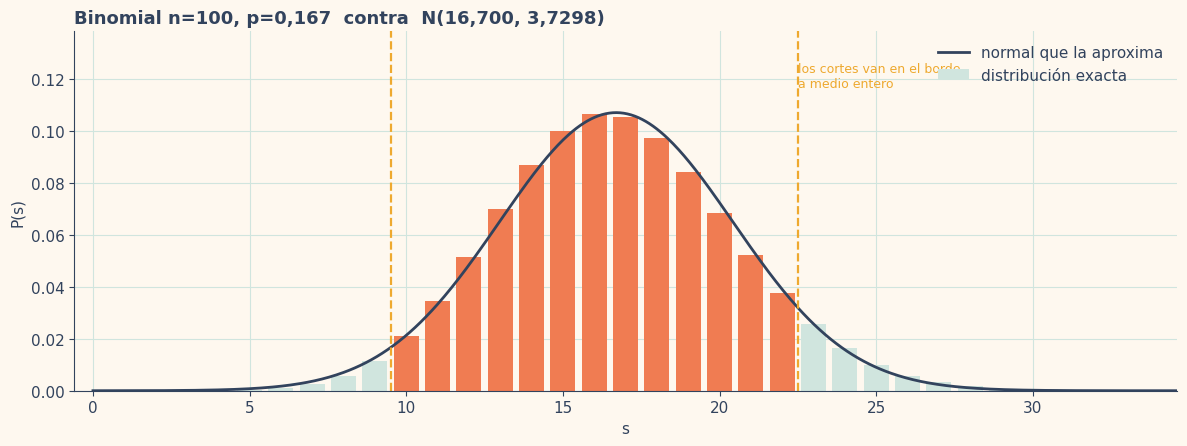

n = 100 y p = 0,167   ✔ n ≥ 30 y 0,1 ≤ p ≤ 0,9: la normal sirve.



,P(10 ≤ s ≤ 22),diferencia con la exacta,en puntos porcentuales
exacta,"0,914915","0,000000","0,000"
"aproximada, sin corrección","0,886124","-0,028792","-2,879"
"aproximada, con corrección","0,913257","-0,001659","-0,166"


La corrección por continuidad no es opcional: es la diferencia entre las dos últimas filas.


In [9]:
#@title Probar una aproximación { run: "auto", display-mode: "form" }

aproximacion = "binomial → normal"  #@param ["hipergeométrica → binomial", "binomial → Poisson", "binomial → normal", "Poisson → normal"]
n = 100  #@param {type:"slider", min:5, max:400, step:5}
p = 0.167  #@param {type:"slider", min:0.01, max:0.99, step:0.001}
poblacion_N = 500  #@param {type:"slider", min:20, max:5000, step:10}
lambda_ = 12.0  #@param {type:"slider", min:0.5, max:40, step:0.5}
desde = 10  #@param {type:"slider", min:0, max:200, step:1}
hasta = 22  #@param {type:"slider", min:0, max:200, step:1}

a, b = sorted([desde, hasta])
q = 1 - p

if aproximacion.startswith("hipergeom"):
    N = poblacion_N
    Np = int(round(N * p))
    n_ext = min(n, N)
    exacta = stats.hypergeom(M=N, n=Np, N=n_ext)
    aprox = stats.binom(n_ext, Np / N)
    continua = False
    condicion = n_ext / N <= 0.05
    linea = (f"n / N = {num(n_ext / N, 4)}   "
             + veredicto(condicion, "no pasa el 5%: la binomial sirve.",
                         "pasa el 5%: la binomial ya no sirve."))
    titulo = f"Hipergeométrica N={N}, Np={Np}, n={n_ext}  contra  binomial n={n_ext}, p={num(Np / N, 4)}"
elif aproximacion.startswith("binomial → Poisson"):
    exacta = stats.binom(n, p)
    lam = n * p if p <= 0.5 else n * q
    aprox = stats.poisson(lam)
    continua = False
    condicion = n >= 30 and (p <= 0.1 or p >= 0.9)
    linea = (f"n = {n} y p = {num(p, 3)}   "
             + veredicto(condicion, "n ≥ 30 con p ≤ 0,1 o p ≥ 0,9: la Poisson sirve.",
                         "hace falta n ≥ 30 y p ≤ 0,1, o bien p ≥ 0,9."))
    titulo = f"Binomial n={n}, p={num(p, 3)}  contra  Poisson λ={num(lam, 3)}"
elif aproximacion.startswith("binomial → normal"):
    exacta = stats.binom(n, p)
    aprox = stats.norm(n * p, np.sqrt(n * p * q))
    continua = True
    condicion = n >= 30 and 0.1 <= p <= 0.9
    linea = (f"n = {n} y p = {num(p, 3)}   "
             + veredicto(condicion, "n ≥ 30 y 0,1 ≤ p ≤ 0,9: la normal sirve.",
                         "hace falta n ≥ 30 y p entre 0,1 y 0,9."))
    titulo = f"Binomial n={n}, p={num(p, 3)}  contra  N({num(n * p, 3)}, {num(np.sqrt(n * p * q), 4)})"
else:
    exacta = stats.poisson(lambda_)
    aprox = stats.norm(lambda_, np.sqrt(lambda_))
    continua = True
    condicion = lambda_ >= 10
    linea = (f"λ = {num(lambda_, 2)}   "
             + veredicto(condicion, "λ ≥ 10: la normal sirve.", "hace falta λ ≥ 10."))
    titulo = f"Poisson λ={num(lambda_, 2)}  contra  N({num(lambda_, 2)}, {num(np.sqrt(lambda_), 4)})"

tope = int(exacta.ppf(0.99995)) + 1
valores = np.arange(0, tope + 1)
pmf = exacta.pmf(valores)
p_exacta = exacta.cdf(b) - exacta.cdf(a - 1)
if continua:
    sin_correccion = aprox.cdf(b) - aprox.cdf(a)
    con_correccion = aprox.cdf(b + 0.5) - aprox.cdf(a - 0.5)
else:
    sin_correccion = np.nan
    con_correccion = aprox.cdf(b) - aprox.cdf(a - 1)

fig, ax = plt.subplots(figsize=(12, 4.6))
colores = [CORAL if a <= v <= b else TEAL_PALIDO for v in valores]
ax.bar(valores, pmf, color=colores, width=0.8, label="distribución exacta")
if continua:
    xs = np.linspace(0, tope + 1, 600)
    ax.plot(xs, aprox.pdf(xs), color=TINTA, linewidth=2, label="normal que la aproxima")
    ax.axvline(a - 0.5, color=MOSTAZA, linewidth=1.6, linestyle="--")
    ax.axvline(b + 0.5, color=MOSTAZA, linewidth=1.6, linestyle="--")
    ax.text(b + 0.5, pmf.max() * 1.1, "los cortes van en el borde,\na medio entero", fontsize=9, color=MOSTAZA)
else:
    ax.plot(valores, aprox.pmf(valores), "o-", color=TINTA, linewidth=1.6, markersize=4,
            label="distribución que la aproxima")
ax.set_xlim(-0.6, tope + 0.6); ax.set_ylim(0, pmf.max() * 1.3)
ax.set_xlabel("s"); ax.set_ylabel("P(s)"); ax.legend(loc="upper right")
ax.set_title(titulo)
plt.tight_layout(); plt.show()

print(linea)
print()
filas = {"exacta": p_exacta}
if continua:
    filas["aproximada, sin corrección"] = sin_correccion
    filas["aproximada, con corrección"] = con_correccion
else:
    filas["aproximada"] = con_correccion
resumen = pd.DataFrame({
    f"P({a} ≤ s ≤ {b})": {k: num(v, 6) for k, v in filas.items()},
    "diferencia con la exacta": {k: num(v - p_exacta, 6) for k, v in filas.items()},
    "en puntos porcentuales": {k: num(100 * (v - p_exacta), 3) for k, v in filas.items()},
})
display(resumen)
if continua:
    print("La corrección por continuidad no es opcional: es la diferencia entre las dos últimas filas.")
else:
    print("Las dos distribuciones son discretas, así que acá la corrección por continuidad no va.")


---
# 8. El teorema de Bernoulli

*Apunte, sección 8.1.*

La cantidad de éxitos en `n` ensayos es binomial, y la **proporción** de éxitos es `X/n`. Su
esperanza es `p` y su desvío es `√[p(1 − p)/n]`, que se achica cuando `n` crece. Eso es el teorema:
al aumentar las repeticiones, la frecuencia relativa se aparta cada vez menos de `p`.

A la izquierda, una secuencia simulada: la línea es la frecuencia relativa acumulada y la franja son
los dos desvíos alrededor de `p`. La franja se angosta y la línea queda adentro.

A la derecha está la otra cara, y es la que corrige el malentendido de la unidad 1. El desvío de la
**proporción** se divide por `√n` y baja; el de la **cantidad** de éxitos es `√(n p q)` y **sube**.
Con 10.000 tiros de una moneda, el desvío de la cantidad de caras es 50 caras.


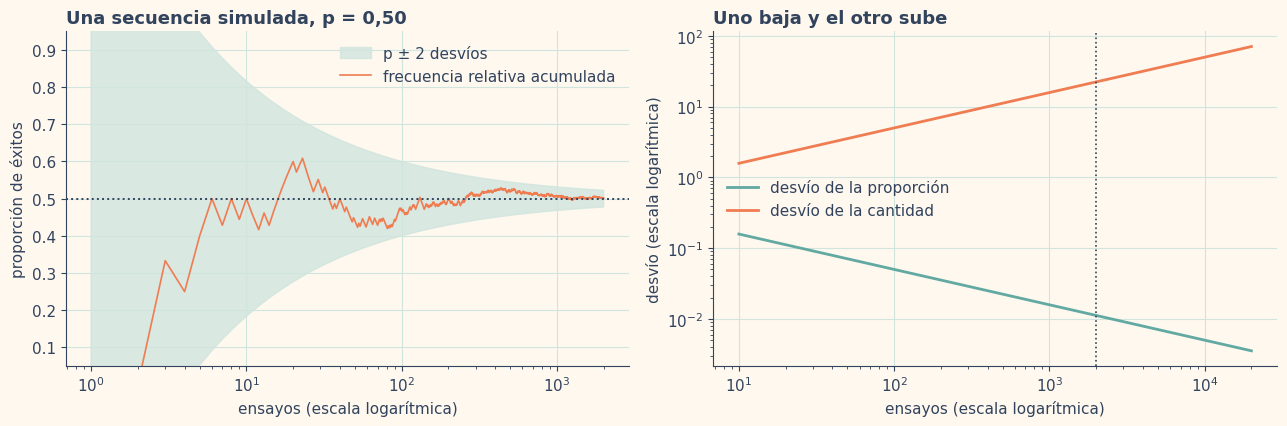

Con 2000 ensayos salieron 1002 éxitos: frecuencia relativa 0,5010, contra p = 0,5000.



,desvío de la proporción,desvío de la cantidad
ensayos,,
10,"0,1581","1,5811"
100,"0,0500","5,0000"
10000,"0,0050","50,0000"


La proporción se estabiliza porque su desvío se divide por √n. La cantidad no: su desvío crece con √n.
Y por la condición 5 de la binomial, ningún resultado anterior cambia la probabilidad del próximo.


In [10]:
#@title La frecuencia relativa se estabiliza { run: "auto", display-mode: "form" }

p = 0.5  #@param {type:"slider", min:0.05, max:0.95, step:0.05}
tiros = 2000  #@param {type:"slider", min:100, max:20000, step:100}
semilla = 1  #@param {type:"slider", min:1, max:50, step:1}

azar = np.random.default_rng(semilla)
salidas = azar.random(tiros) < p
frecuencia = np.cumsum(salidas) / np.arange(1, tiros + 1)
eje = np.arange(1, tiros + 1)
banda = 2 * np.sqrt(p * (1 - p) / eje)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
ax1.fill_between(eje, p - banda, p + banda, color=TEAL_PALIDO, alpha=0.8, label="p ± 2 desvíos")
ax1.plot(eje, frecuencia, color=CORAL, linewidth=1.2, label="frecuencia relativa acumulada")
ax1.axhline(p, color=TINTA, linewidth=1.4, linestyle=":")
ax1.set_xscale("log"); ax1.set_ylim(max(0, p - 0.45), min(1, p + 0.45))
ax1.set_xlabel("ensayos (escala logarítmica)"); ax1.set_ylabel("proporción de éxitos")
ax1.legend(loc="upper right"); ax1.set_title(f"Una secuencia simulada, p = {num(p, 2)}")

tamanos = np.geomspace(10, 20000, 60)
ax2.plot(tamanos, np.sqrt(p * (1 - p) / tamanos), color=TEAL, linewidth=2, label="desvío de la proporción")
ax2.plot(tamanos, np.sqrt(tamanos * p * (1 - p)), color=CORAL, linewidth=2, label="desvío de la cantidad")
ax2.axvline(tiros, color=TINTA, linestyle=":", linewidth=1.2)
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("ensayos (escala logarítmica)"); ax2.set_ylabel("desvío (escala logarítmica)")
ax2.legend(loc="center left"); ax2.set_title("Uno baja y el otro sube")
plt.tight_layout(); plt.show()

print(f"Con {tiros} ensayos salieron {int(salidas.sum())} éxitos: frecuencia relativa {num(frecuencia[-1], 4)}, "
      f"contra p = {num(p, 4)}.")
print()
display(pd.DataFrame({
    "desvío de la proporción": {t: num(np.sqrt(p * (1 - p) / t), 4) for t in (10, 100, 10000)},
    "desvío de la cantidad": {t: num(np.sqrt(t * p * (1 - p)), 4) for t in (10, 100, 10000)},
}).rename_axis("ensayos"))
print("La proporción se estabiliza porque su desvío se divide por √n. La cantidad no: su desvío crece con √n.")
print("Y por la condición 5 de la binomial, ningún resultado anterior cambia la probabilidad del próximo.")


---
# 9. El teorema central del límite

*Apunte, secciones 8.2 a 8.6.*

El teorema dice que la distribución de la **media muestral** se acerca a una normal a medida que `n`
crece, **cualquiera sea la forma de la población**. Y dice también el centro y el ancho: `E(X̄) = μ`
y `σ(X̄) = σ / √n`, que se llama **error standard de la media**.

La población de fábrica son los 35 ingresos declarados del relevamiento, con asimetría 2,87 por el
hogar de 620.000. Subí el tamaño de muestra y mirá las tres cosas de la sección 8.5: el centro no se
mueve, el ancho se achica como dice `σ / √n`, y la asimetría se va.

Y mirá también lo que el teorema **no** dice. El panel de la izquierda es la población, y sigue
igual de estirada con cualquier tamaño de muestra. Con esta población, `n = 30` todavía deja una
asimetría de 0,52, así que el umbral de 30 es una regla práctica y no una garantía.


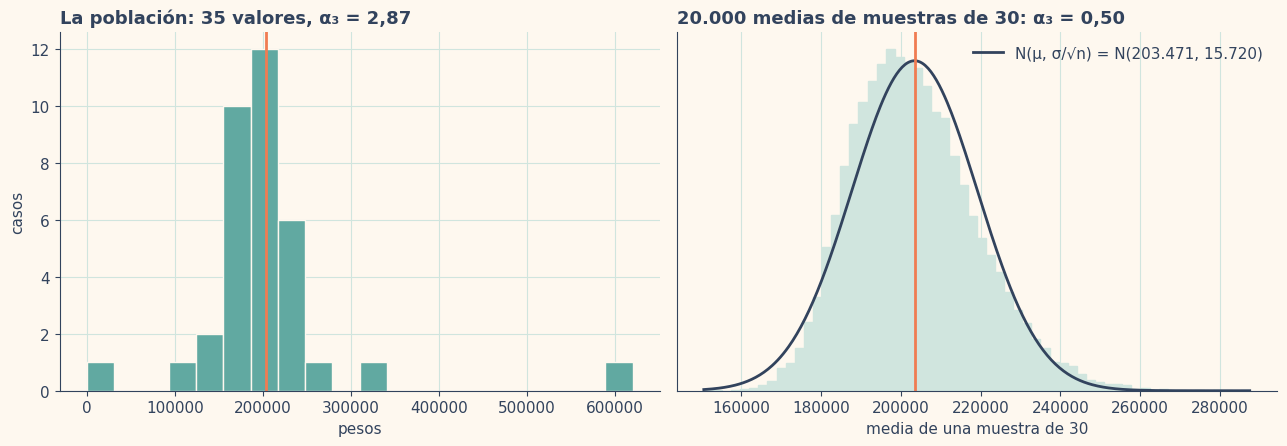

,media de las medias,desvío observado,σ / √n,asimetría
tamaño de muestra,,,,
2,204.097,61.127,60.884,"2,01"
5,203.658,38.467,38.506,"1,30"
30,203.547,15.770,15.720,"0,53"
100,203.440,8.627,8.610,"0,27"


Población: μ = 203.471   σ = 86.103   α₃ = 2,8714
Muestras de 30: media de las medias 203.345, desvío observado 15.652, y σ / √n = 15.720.
El desvío de la variable describe cuánto varía un dato; el error standard, cuánto varía un promedio.
Para partir el error standard al medio hay que cuadruplicar la muestra: con n = 120 daría 7.860.


In [11]:
#@title La distribución de la media muestral { run: "auto", display-mode: "form" }

poblacion = "ingreso del relevamiento"  #@param ["ingreso del relevamiento", "personas por hogar", "uniforme entre 0 y 1", "muy asimétrica (exponencial)"]
tamano_de_muestra = 30  #@param {type:"slider", min:1, max:100, step:1}
cantidad_de_muestras = 20000  #@param {type:"slider", min:2000, max:60000, step:2000}
semilla = 1  #@param {type:"slider", min:1, max:50, step:1}

azar = np.random.default_rng(semilla)
n = tamano_de_muestra
if poblacion.startswith("ingreso"):
    datos = hogares["ingreso"].dropna().to_numpy(dtype=float)
    unidad = "pesos"
elif poblacion.startswith("personas"):
    datos = hogares["personas"].to_numpy(dtype=float)
    unidad = "personas"
elif poblacion.startswith("uniforme"):
    datos = azar.random(4000)
    unidad = ""
else:
    datos = azar.exponential(1.0, 4000)
    unidad = ""

mu, sigma = datos.mean(), datos.std(ddof=0)
muestras = azar.choice(datos, size=(cantidad_de_muestras, n), replace=True)
medias = muestras.mean(axis=1)
error_standard = sigma / np.sqrt(n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
ax1.hist(datos, bins=20, color=TEAL, edgecolor=CREMA)
ax1.axvline(mu, color=CORAL, linewidth=2)
ax1.set_title(f"La población: {len(datos)} valores, α₃ = {num(stats.skew(datos), 2)}")
ax1.set_xlabel(unidad or "valor"); ax1.set_ylabel("casos")
ax2.hist(medias, bins=60, density=True, color=TEAL_PALIDO, edgecolor=TEAL_PALIDO)
xs = np.linspace(medias.min(), medias.max(), 400)
ax2.plot(xs, stats.norm(mu, error_standard).pdf(xs), color=TINTA, linewidth=2,
         label=f"N(μ, σ/√n) = N({num(mu, 0)}, {num(error_standard, 0)})")
ax2.axvline(mu, color=CORAL, linewidth=2)
ax2.set_yticks([]); ax2.legend(loc="upper right")
ax2.set_xlabel(f"media de una muestra de {n}")
ax2.set_title(f"{cantidad_de_muestras:,}".replace(",", ".") + f" medias de muestras de {n}: α₃ = {num(stats.skew(medias), 2)}")
plt.tight_layout(); plt.show()

filas = []
for tamano in (2, 5, 30, 100):
    m = azar.choice(datos, size=(min(cantidad_de_muestras, 20000), tamano), replace=True).mean(axis=1)
    filas.append({"tamaño de muestra": tamano, "media de las medias": num(m.mean(), 0),
                  "desvío observado": num(m.std(ddof=0), 0), "σ / √n": num(sigma / np.sqrt(tamano), 0),
                  "asimetría": num(stats.skew(m), 2)})
display(pd.DataFrame(filas).set_index("tamaño de muestra"))
print(f"Población: μ = {num(mu, 0)}   σ = {num(sigma, 0)}   α₃ = {num(stats.skew(datos), 4)}")
print(f"Muestras de {n}: media de las medias {num(medias.mean(), 0)}, desvío observado "
      f"{num(medias.std(ddof=0), 0)}, y σ / √n = {num(error_standard, 0)}.")
print("El desvío de la variable describe cuánto varía un dato; el error standard, cuánto varía un promedio.")
print(f"Para partir el error standard al medio hay que cuadruplicar la muestra: con n = {4 * n} daría "
      f"{num(sigma / np.sqrt(4 * n), 0)}.")


---
# 10. Las tres distribuciones de la inferencia

*Apunte, secciones 9.2 a 9.6.*

Las tres últimas no describen ningún fenómeno: describen **cuentas hechas sobre una muestra**. Las
tres se construyen a partir de la normal standard y las tres tienen un parámetro con el mismo
nombre, los **grados de libertad**: cuántos valores pueden variar libremente después de imponer las
restricciones del cálculo.

- La **chi cuadrado** es una suma de cuadrados de normales standard. Nunca es negativa y se estira a
  la derecha; con muchos grados de libertad se acerca a una campana.
- La **t de Student** es lo que sigue la media estandarizada cuando `σ` se estima con la muestra. Se
  parece a la normal, con el pico más bajo y las colas más pesadas.
- La **F** es el cociente de dos chi cuadrado promedio. Tiene dos parámetros de grados de libertad,
  y el orden importa.

La tabla de la t es la de la sección 9.4: el valor que deja el 2,5% en la cola derecha, que es el
que arma un intervalo del 95%. Con pocos grados de libertad hay que ir bastante más lejos que con la
normal; con 100 la diferencia casi no existe.


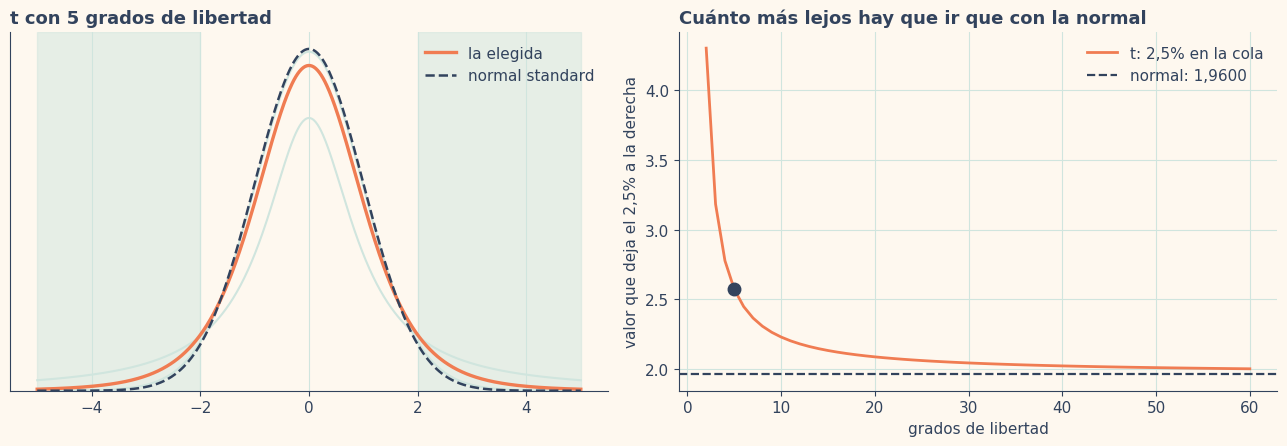

El valor que deja el 5% en la cola derecha: 2,0150
El valor que deja el 2,5% en la cola derecha: 2,5706



,"valor de t que deja el 2,5% a la derecha"
grados de libertad,
5,"2,5706"
10,"2,2281"
30,"2,0423"
100,"1,9840"
normal standard,"1,9600"


Control de la sección 9.6: una t con 5 gl elevada al cuadrado es una F con 1 y 5 gl.
  t(5).ppf(0,975)² = 6,6079     F(1, 5).ppf(0,95) = 6,6079


In [12]:
#@title Chi cuadrado, t de Student y F { run: "auto", display-mode: "form" }

distribucion = "t de Student"  #@param ["chi cuadrado", "t de Student", "F de Fisher-Snedecor"]
grados_de_libertad = 5  #@param {type:"slider", min:1, max:60, step:1}
grados_del_denominador = 10  #@param {type:"slider", min:1, max:60, step:1}

gl, gl2 = grados_de_libertad, grados_del_denominador
if distribucion.startswith("chi"):
    X = stats.chi2(gl)
    xs = np.linspace(0.001, max(X.ppf(0.995), 10), 600)
    referencia = {otro: stats.chi2(otro) for otro in (1, 5, 20)}
    titulo = f"χ² con {gl} grados de libertad: E = {num(gl, 0)}, σ² = {num(2 * gl, 0)}"
elif distribucion.startswith("t de"):
    X = stats.t(gl)
    xs = np.linspace(-5, 5, 600)
    referencia = {otro: stats.t(otro) for otro in (1, 5, 30)}
    titulo = f"t con {gl} grados de libertad"
else:
    X = stats.f(gl, gl2)
    xs = np.linspace(0.001, max(X.ppf(0.99), 4), 600)
    referencia = {}
    titulo = f"F con {gl} y {gl2} grados de libertad"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
for otro, Y in referencia.items():
    ax1.plot(xs, Y.pdf(xs), color=TEAL_PALIDO, linewidth=1.5)
ax1.plot(xs, X.pdf(xs), color=CORAL, linewidth=2.4, label="la elegida")
if distribucion.startswith("t de"):
    ax1.plot(xs, stats.norm.pdf(xs), color=TINTA, linewidth=1.8, linestyle="--", label="normal standard")
    ax1.axvspan(-5, -2, color=TEAL_PALIDO, alpha=0.5); ax1.axvspan(2, 5, color=TEAL_PALIDO, alpha=0.5)
elif distribucion.startswith("F"):
    ax1.plot(xs, stats.f(gl2, gl).pdf(xs), color=TINTA, linewidth=1.6, linestyle="--",
             label=f"F con {gl2} y {gl}: no es la misma")
ax1.set_ylim(0, None); ax1.set_yticks([]); ax1.legend(loc="upper right")
ax1.set_title(titulo)

if distribucion.startswith("t de"):
    grados = np.arange(2, 61)
    ax2.plot(grados, stats.t(grados).ppf(0.975), color=CORAL, linewidth=2, label="t: 2,5% en la cola")
    ax2.axhline(stats.norm.ppf(0.975), color=TINTA, linestyle="--", linewidth=1.6, label="normal: 1,9600")
    ax2.plot([gl], [stats.t(gl).ppf(0.975)], "o", color=TINTA, markersize=9)
    ax2.set_xlabel("grados de libertad"); ax2.set_ylabel("valor que deja el 2,5% a la derecha")
    ax2.legend(loc="upper right"); ax2.set_title("Cuánto más lejos hay que ir que con la normal")
else:
    for otro, color in zip((1, 5, 20, 50), [MOSTAZA, CORAL, TEAL, TINTA]):
        Y = stats.chi2(otro) if distribucion.startswith("chi") else stats.f(otro, gl2)
        rango = np.linspace(0.001, max(X.ppf(0.995), 10), 600)
        ax2.plot(rango, Y.pdf(rango), color=color, linewidth=1.8, label=f"gl = {otro}")
    ax2.set_ylim(0, None); ax2.set_yticks([]); ax2.legend(loc="upper right")
    ax2.set_title("La asimetría se atenúa cuando crecen los grados de libertad")
plt.tight_layout(); plt.show()

print(f"El valor que deja el 5% en la cola derecha: {num(X.ppf(0.95), 4)}")
print(f"El valor que deja el 2,5% en la cola derecha: {num(X.ppf(0.975), 4)}")
print()
display(pd.DataFrame({
    "valor de t que deja el 2,5% a la derecha": {
        **{g: num(stats.t(g).ppf(0.975), 4) for g in (5, 10, 30, 100)},
        "normal standard": num(stats.norm.ppf(0.975), 4)},
}).rename_axis("grados de libertad"))
print(f"Control de la sección 9.6: una t con {gl} gl elevada al cuadrado es una F con 1 y {gl} gl.")
print(f"  t({gl}).ppf(0,975)² = {num(stats.t(gl).ppf(0.975) ** 2, 4)}     "
      f"F(1, {gl}).ppf(0,95) = {num(stats.f(1, gl).ppf(0.95), 4)}")


---
## Cierre

Diez formularios, y en todos se puede volver a cambiar algo:

1. La familia binomial, y qué hace cada uno de sus dos parámetros.
2. La fórmula de la binomial, factor por factor, contra `scipy`.
3. La multinomial de las facturas, y el control con dos binomiales sucesivas.
4. La hipergeométrica, el factor de corrección y el límite del 5%.
5. La Poisson, y el cambio de escala del intervalo.
6. La normal: las tres franjas, el área y el camino inverso.
7. Las cuatro aproximaciones, y la corrección por continuidad.
8. El teorema de Bernoulli, con la proporción y la cantidad.
9. El teorema central del límite sobre el ingreso del relevamiento.
10. La chi cuadrado, la t de Student y la F.

Quedan afuera, porque se entienden leyendo, la polinomial de la sección 4.5 y las tablas impresas de
la sección 6.6.

> **Apunte de la unidad 3:**
> [E8102_Apunte_U3_Distribuciones.pdf](https://github.com/lautarodibartolo-ae/e8102-exploracion-de-datos/blob/main/bloque-2-distribuciones-y-analisis-de-datos/E8102_Apunte_U3_Distribuciones.pdf)
